In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from scipy import stats
from helperfuncs import *
import matplotlib as mpl
from statsmodels.stats.multitest import multipletests
import os

### 1. Import source data and gene names

#### 1.1. Load DESeq2 differential expression statistics

In [2]:
MA2_vs_mock_MCF7 = load_data_from_csv("deseq2counts/LY_FBS10-MCF7_MA2_vs_mock.csv")
diABZI_vs_mock_MCF7 = load_data_from_csv("deseq2counts/LY_FBS10-MCF7_diABZI_vs_mock.csv")

MA2_vs_mock_HCC2429 = load_data_from_csv("deseq2counts/LY_FBS10-HCC2429_MA2_vs_mock.csv")
diABZI_vs_mock_HCC2429 = load_data_from_csv("deseq2counts/LY_FBS10-HCC2429_diABZI_vs_mock.csv")

#load_data_from_csv(filepath)  returns [0]headers, [1]gene_id, [2]numerical_data
#numerical data columns:
#np.str_('"[0]baseMean"'), np.str_('"[1]log2FoldChange"'), np.str_('"[2]lfcSE"'), np.str_('"[3]stat"'), np.str_('"[4]pvalue"'), np.str_('"[5]padj"')]
print(MA2_vs_mock_HCC2429[2].shape) #print example matrix shape as validation

Successfully loaded deseq2counts/LY_FBS10-MCF7_MA2_vs_mock.csv
Successfully loaded deseq2counts/LY_FBS10-MCF7_diABZI_vs_mock.csv
Successfully loaded deseq2counts/LY_FBS10-HCC2429_MA2_vs_mock.csv
Successfully loaded deseq2counts/LY_FBS10-HCC2429_diABZI_vs_mock.csv
(20053, 6)


#### 1.2. Load DESeq2-normalized count matrix

In [3]:
MCF7_headers, MCF7_geneids, MCF7_matrix = load_data_from_csv("deseq2counts/LY_FBS10-MCF7_counts_DDSnormalized.csv")

#Rearrange matrix columns: Convert from lexicographical order (original matrix) to the desired sample column order
original_order_MCF7 = []
for i in range(1, len(MCF7_headers)):
    original_order_MCF7.append(MCF7_headers[i].strip('"')) #sample names starts at MCF7_headers[1] since MCF7_headers[0] corresponds to geneIDs
desired_order_MCF7 = ["FBS10-MCF7-mock-1", "FBS10-MCF7-mock-2", "FBS10-MCF7-MA2-1", "FBS10-MCF7-MA2-2", "FBS10-MCF7-diABZI-1", "FBS10-MCF7-diABZI-2" ]
new_order_MCF7 = [original_order_MCF7.index(x) for x in desired_order_MCF7]
print("Original col order:", original_order_MCF7, "\nDesired order:", desired_order_MCF7, "\nReordering columns:", new_order_MCF7)
MCF7_matrx_reordered = MCF7_matrix[:, new_order_MCF7]


HCC2429_headers, HCC2429_geneids, HCC2429_matrix = load_data_from_csv("deseq2counts/LY_FBS10-HCC2429_counts_DDSnormalized.csv")
original_order_HCC = []
for i in range(1, len(HCC2429_headers)):
    original_order_HCC.append(HCC2429_headers[i].strip('"')) #sample names starts at MCF7_headers[1] since MCF7_headers[0] corresponds to geneIDs
desired_order_HCC = ["FBS10-HCC2429-mock-1", "FBS10-HCC2429-mock-2", "FBS10-HCC2429-MA2-1", "FBS10-HCC2429-MA2-2",
                    "FBS10-HCC2429-diABZI-1", "FBS10-HCC2429-diABZI-2"]
new_order_HCC = [original_order_HCC.index(x) for x in desired_order_HCC]
print("Original col order:", original_order_HCC, "\nDesired order:", desired_order_HCC, "\nReordering columns:", new_order_HCC)
HCC2429_matrx_reordered = HCC2429_matrix[:, new_order_HCC]


Successfully loaded deseq2counts/LY_FBS10-MCF7_counts_DDSnormalized.csv
Original col order: ['FBS10-MCF7-diABZI-1', 'FBS10-MCF7-diABZI-2', 'FBS10-MCF7-MA2-1', 'FBS10-MCF7-MA2-2', 'FBS10-MCF7-mock-1', 'FBS10-MCF7-mock-2'] 
Desired order: ['FBS10-MCF7-mock-1', 'FBS10-MCF7-mock-2', 'FBS10-MCF7-MA2-1', 'FBS10-MCF7-MA2-2', 'FBS10-MCF7-diABZI-1', 'FBS10-MCF7-diABZI-2'] 
Reordering columns: [4, 5, 2, 3, 0, 1]
Successfully loaded deseq2counts/LY_FBS10-HCC2429_counts_DDSnormalized.csv
Original col order: ['FBS10-HCC2429-diABZI-1', 'FBS10-HCC2429-diABZI-2', 'FBS10-HCC2429-MA2-1', 'FBS10-HCC2429-MA2-2', 'FBS10-HCC2429-mock-1', 'FBS10-HCC2429-mock-2'] 
Desired order: ['FBS10-HCC2429-mock-1', 'FBS10-HCC2429-mock-2', 'FBS10-HCC2429-MA2-1', 'FBS10-HCC2429-MA2-2', 'FBS10-HCC2429-diABZI-1', 'FBS10-HCC2429-diABZI-2'] 
Reordering columns: [4, 5, 2, 3, 0, 1]


#### 1.3. Load and generate gene ID to gene names mapping

In [4]:
genenames_encodeV43 = np.genfromtxt("gencodev43_proteinCodingOnly_ENSG_version-gene_type-gene_name.tsv", 
                             delimiter="\t", dtype='str') #columns: ENSG (With version ID), "protein_coding", geneName
#Build dict
genenames_encV43_dict = {}
for row_id in range(genenames_encodeV43.shape[0]):
    genenames_encV43_dict[genenames_encodeV43[row_id,0].strip("'\"")] = genenames_encodeV43[row_id,2]

genenames_MCF7 = np.copy(MCF7_geneids)
new_col = np.empty(genenames_MCF7.shape[0], dtype=genenames_encodeV43.dtype) #set dtype to genenames_encodeV43.dtype exact dtype avoids U1 truncation
for idx in range(new_col.shape[0]):
    new_col[idx] = genenames_encV43_dict[str(genenames_MCF7[idx].strip("'\""))]
genenames_MCF7 = np.c_[genenames_MCF7, new_col]


genenames_HCC2429 = np.copy(HCC2429_geneids)
new_col = np.empty(genenames_HCC2429.shape[0], dtype=genenames_encodeV43.dtype) #set dtype to genenames_encodeV43.dtype exact dtype avoids U1 truncation
for idx in range(new_col.shape[0]):
    new_col[idx] = genenames_encV43_dict[str(genenames_HCC2429[idx].strip("'\""))]
genenames_HCC2429 = np.c_[genenames_HCC2429, new_col]

print("Finished gene ID to gene names mapping.")

Finished gene ID to gene names mapping.


#### 1.4. Compute filters for low-count genes

In [5]:
avg_expr_cutoff = 5

low_expr_mask_MCF7 = np.sum(MCF7_matrx_reordered, axis=1) < avg_expr_cutoff
print(low_expr_mask_MCF7.shape, np.sum(~low_expr_mask_MCF7)) #~ means not in, i.e. those passing the threshold

low_expr_mask_HCC2429 = np.sum(HCC2429_matrx_reordered, axis=1) < avg_expr_cutoff
print(low_expr_mask_HCC2429.shape, np.sum(~low_expr_mask_HCC2429)) #~ means not in, i.e. those passing the threshold

(20053,) 14441
(20053,) 17008


In [6]:
# Generate output directories
os.makedirs("output_figures", exist_ok=True)
os.makedirs("output_files", exist_ok=True)


### 2. Plot volcano plots using DESeq2 differential expression statistics

#### 2.1. HCC2429, MA2/mock

L2FC cutoff: 1
Num sig upregulated genes: 101.  Num sig downregulated genes: 4
(20053,)
STAT1 0.0 -inf
OAS3 0.0 -inf
HELZ2 0.0 -inf


C:\Users\Y3961\AppData\Local\Temp\ipykernel_29980\2603781489.py:40: RuntimeWarning: divide by zero encountered in log10
  print(genenames_data[:,1][gene], padjs[gene], np.log10(padjs[gene]))


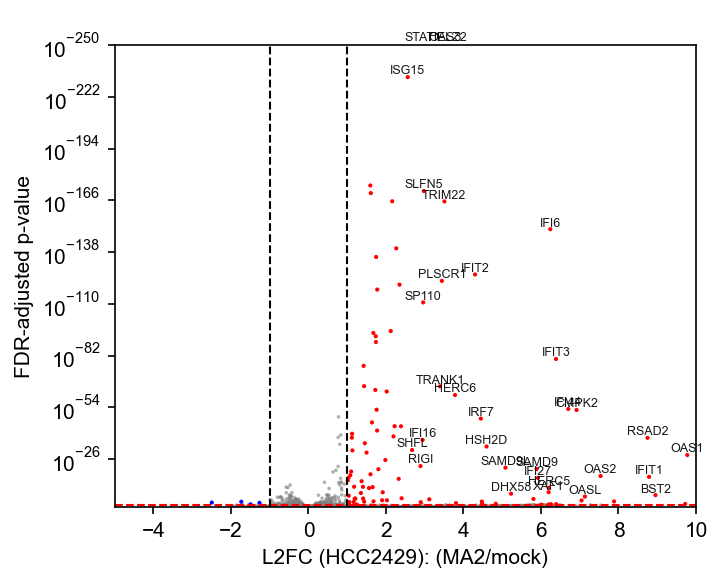

In [7]:
l2fc_cutoff=1
print("L2FC cutoff: "+str(l2fc_cutoff))
genenames_data = genenames_HCC2429

MA2_up_HCC2429 = (MA2_vs_mock_HCC2429[2][:,1] > l2fc_cutoff) & (MA2_vs_mock_HCC2429[2][:,5] < 0.05) & (~low_expr_mask_HCC2429)
MA2_down_HCC2429 = (MA2_vs_mock_HCC2429[2][:,1] < -l2fc_cutoff) & (MA2_vs_mock_HCC2429[2][:,5] < 0.05) & (~low_expr_mask_HCC2429)
print("Num sig upregulated genes: "+str(np.sum(MA2_up_HCC2429))+".  Num sig downregulated genes: "+str(np.sum(MA2_down_HCC2429)))

#make font editable
mpl.rcParams['svg.fonttype']='none' #This is the key line for making SVG text editable
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots(figsize=(5,4),dpi=150)

subplots_titles = [' ']
datasets_names = ['(MA2/mock)']
l2fc_datasets = [MA2_vs_mock_HCC2429[2][:,1]]
padj_datasets = [MA2_vs_mock_HCC2429[2][:,5]]

axs=[ax]

for i in range(len(axs)):
    fc_datasetlabel = datasets_names[i]
    l2fc_dataset = l2fc_datasets[i]
    padjs = padj_datasets[i]
    print(l2fc_dataset.shape)
    
    axs[i].scatter(l2fc_dataset[(~(MA2_up_HCC2429|MA2_down_HCC2429))&(~low_expr_mask_HCC2429)], 
                   padjs[(~(MA2_up_HCC2429|MA2_down_HCC2429))&(~low_expr_mask_HCC2429)], s=3, alpha=0.6, color='grey', 
                   edgecolor='none') #rasterized=True allows it to be flattened during SVG
    axs[i].scatter(l2fc_dataset[MA2_up_HCC2429], padjs[MA2_up_HCC2429], s=4, alpha=1, color='red', edgecolor='none')
    axs[i].scatter(l2fc_dataset[MA2_down_HCC2429], padjs[MA2_down_HCC2429], s=4, alpha=1, color='blue', edgecolor='none')

    for gene in np.where(MA2_up_HCC2429)[0]:
        txt_color = 'black'
        alphaval = 0.9
        if l2fc_dataset[gene]>2.5 and padjs[gene]<1e-5:
            if padjs[gene] < 1e-250:
                print(genenames_data[:,1][gene], padjs[gene], np.log10(padjs[gene]))
                axs[i].text(l2fc_dataset[gene], 1e-251, genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)
            else:
                axs[i].text(l2fc_dataset[gene], padjs[gene], genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)
     
    axs[i].set_xlim(-5, 10)
    axs[i].set_ylim(1, 1e-250)
    axs[i].axhline(0.05, color='red', linestyle='--', linewidth=1)
    #axs[i].text(2.9, 0.048, 'p=0.05', color='red', horizontalalignment='right')
    axs[i].axvline(l2fc_cutoff, color='black', linestyle='--', linewidth=1)
    axs[i].axvline(-l2fc_cutoff, color='black', linestyle='--', linewidth=1)
    axs[i].semilogy()
    axs[i].set_title(subplots_titles[i])
    axs[i].set_xlabel('L2FC (HCC2429): '+datasets_names[i])
    #axs[i].legend(loc='upper right', fancybox=False)

axs[0].set_ylabel('FDR-adjusted p-value')

#Now save as svg
plt.savefig("output_figures/Fig_HCC2429-MA2up-RNAseq-Volcano_LabelCutoffL2fc2p5-pval1e-5.svg")


##### 2.1.a. Save the list of the significantly differentially regulated genes to txt file

In [8]:
MA2up_file = open("output_files/MA2up_HCC2429.txt","w")
MA2up_file.write("Names of all genes whose L2FC>"+str(l2fc_cutoff)+", padj<0.05\n")
for gene in np.where(MA2_up_HCC2429)[0]:
    MA2up_file.write(genenames_data[:,1][gene]+'\n')
MA2up_file.close()

In [9]:
MA2down_file = open("output_files/MA2down_HCC2429.txt","w")
MA2down_file.write("Names of all genes whose L2FC<"+str(-l2fc_cutoff)+", padj<0.05\n")
for gene in np.where(MA2_down_HCC2429)[0]:
    MA2down_file.write(genenames_data[:,1][gene]+'\n')
MA2down_file.close()

#### 2.2. HCC2429, diABZI/mock

L2FC cutoff: 1
diABZI up: 76 	 diABZI down: 16
(20053,)


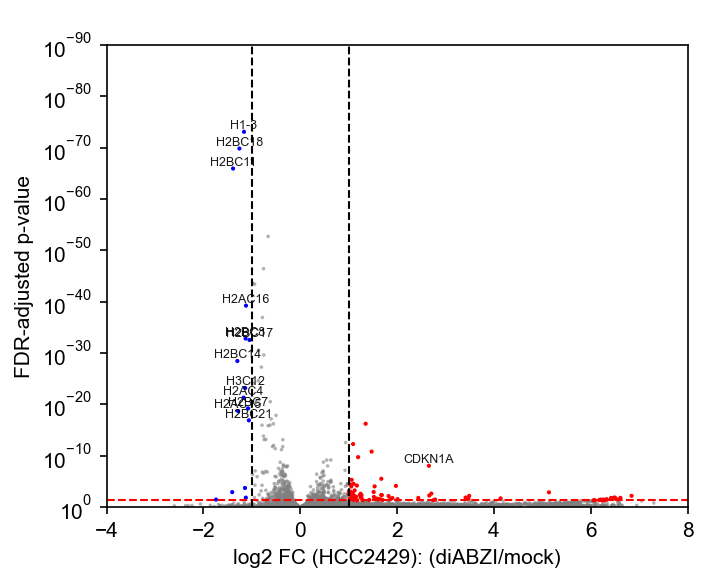

In [10]:
#diABZI genes
l2fc_cutoff=1
print("L2FC cutoff: "+str(l2fc_cutoff))
genenames_data = genenames_HCC2429

diABZI_up_HCC2429 = (diABZI_vs_mock_HCC2429[2][:,1] > l2fc_cutoff) & (diABZI_vs_mock_HCC2429[2][:,5] < 0.05) & (~low_expr_mask_HCC2429)
diABZI_down_HCC2429 = (diABZI_vs_mock_HCC2429[2][:,1] < -l2fc_cutoff) & (diABZI_vs_mock_HCC2429[2][:,5] < 0.05) & (~low_expr_mask_HCC2429)
print("diABZI up:", np.sum(diABZI_up_HCC2429), "\t diABZI down:", np.sum(diABZI_down_HCC2429))
#make font editable
mpl.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots(figsize=(5,4),dpi=150)

subplots_titles = [' ']
datasets_names = ['(diABZI/mock)']
l2fc_datasets = [diABZI_vs_mock_HCC2429[2][:,1]]
padj_datasets = [diABZI_vs_mock_HCC2429[2][:,5]]

axs=[ax]

for i in range(len(axs)):
    fc_datasetlabel = datasets_names[i]
    l2fc_dataset = l2fc_datasets[i]
    padjs = padj_datasets[i]
    print(l2fc_dataset.shape)
    
    axs[i].scatter(l2fc_dataset[(~(diABZI_up_HCC2429|diABZI_down_HCC2429))&(~low_expr_mask_HCC2429)], 
                   padjs[(~(diABZI_up_HCC2429|diABZI_down_HCC2429))&(~low_expr_mask_HCC2429)], s=3, 
                   alpha=0.6, color='grey', edgecolor='none') 
    axs[i].scatter(l2fc_dataset[diABZI_up_HCC2429], padjs[diABZI_up_HCC2429], s=4, alpha=1, color='red', edgecolor='none')
    axs[i].scatter(l2fc_dataset[diABZI_down_HCC2429], padjs[diABZI_down_HCC2429], s=4, alpha=1, color='blue', edgecolor='none')

    for gene in np.where(diABZI_up_HCC2429)[0]:
        txt_color = 'black'
        alphaval = 0.9
        if l2fc_dataset[gene]>2.5 and padjs[gene]<1e-5:
            if padjs[gene] < 1e-250:
                print(genenames_data[:,1][gene], padjs[gene], np.log10(padjs[gene]))
                axs[i].text(l2fc_dataset[gene], 1e-251, genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)
            else:
                axs[i].text(l2fc_dataset[gene], padjs[gene], genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)

    for gene in np.where(diABZI_down_HCC2429)[0]:
        txt_color = 'black'
        alphaval = 0.9
        if l2fc_dataset[gene]<-1 and padjs[gene]<1e-5:
            if padjs[gene] < 1e-250:
                print(genenames_data[:,1][gene], padjs[gene], np.log10(padjs[gene]))
                axs[i].text(l2fc_dataset[gene], 1e-251, genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)
            else:
                axs[i].text(l2fc_dataset[gene], padjs[gene], genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)
    
     
    axs[i].set_xlim(-4, 8)
    axs[i].set_ylim(1, 1e-90)
    axs[i].axhline(0.05, color='red', linestyle='--', linewidth=1)
    #axs[i].text(2.9, 0.048, 'p=0.05', color='red', horizontalalignment='right')
    axs[i].axvline(l2fc_cutoff, color='black', linestyle='--', linewidth=1)
    axs[i].axvline(-l2fc_cutoff, color='black', linestyle='--', linewidth=1)
    axs[i].semilogy()
    axs[i].set_title(subplots_titles[i])
    axs[i].set_xlabel('log2 FC (HCC2429): '+datasets_names[i])
    #axs[i].legend(loc='upper right', fancybox=False)

axs[0].set_ylabel('FDR-adjusted p-value')

#Now save as svg
plt.savefig("output_figures/Fig_HCC2429-diABZIup-and-downRNAseq-Volcano_LabelCutoffL2fc_-1to2p5-pval1e-5.svg")


##### 2.2.a. Save the list of the significantly differentially regulated genes to txt file

In [11]:
diABZIup_file = open("output_files/diABZIup_HCC2429.txt","w")
diABZIup_file.write("Names of all genes whose L2FC>"+str(l2fc_cutoff)+", padj<0.05\n")
for gene in np.where(diABZI_up_HCC2429)[0]:
    diABZIup_file.write(genenames_data[:,1][gene]+'\n')
diABZIup_file.close()

diABZIdown_file = open("output_files/diABZIdown_HCC2429.txt","w")
diABZIdown_file.write("Names of all genes whose L2FC<"+str(-l2fc_cutoff)+", padj<0.05\n")
for gene in np.where(diABZI_down_HCC2429)[0]:
    diABZIdown_file.write(genenames_data[:,1][gene]+'\n')
diABZIdown_file.close()

#### 2.3. MCF-7 (FBS10), MA2/mock

L2FC cutoff: 1
Num sig upregulated genes: 29.  Num sig downregulated genes: 4
(20053,)


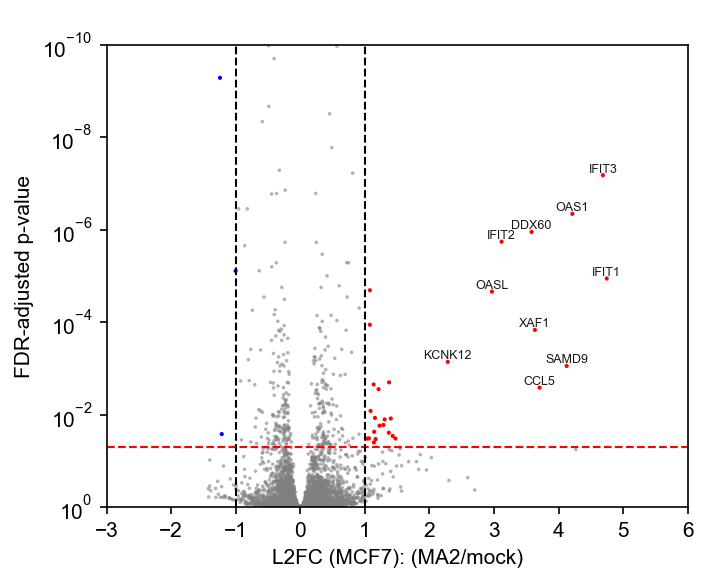

In [12]:
l2fc_cutoff=1
print("L2FC cutoff: "+str(l2fc_cutoff))
genenames_data = genenames_MCF7

MA2_up_MCF7 = (MA2_vs_mock_MCF7[2][:,1] > l2fc_cutoff) & (MA2_vs_mock_MCF7[2][:,5] < 0.05) & (~low_expr_mask_MCF7)
MA2_down_MCF7 = (MA2_vs_mock_MCF7[2][:,1] < -l2fc_cutoff) & (MA2_vs_mock_MCF7[2][:,5] < 0.05) & (~low_expr_mask_MCF7)
print("Num sig upregulated genes: "+str(np.sum(MA2_up_MCF7))+".  Num sig downregulated genes: "+str(np.sum(MA2_down_MCF7)))

#make font editable
mpl.rcParams['svg.fonttype']='none' #This is the key line for making SVG text editable
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots(figsize=(5,4),dpi=150)

subplots_titles = [' ']
datasets_names = ['(MA2/mock)']
l2fc_datasets = [MA2_vs_mock_MCF7[2][:,1]]
padj_datasets = [MA2_vs_mock_MCF7[2][:,5]]

axs=[ax]

for i in range(len(axs)):
    fc_datasetlabel = datasets_names[i]
    l2fc_dataset = l2fc_datasets[i]
    padjs = padj_datasets[i]
    print(l2fc_dataset.shape)
    
    axs[i].scatter(l2fc_dataset[(~(MA2_up_MCF7|MA2_down_MCF7))&(~low_expr_mask_MCF7)], 
                   padjs[(~(MA2_up_MCF7|MA2_down_MCF7))&(~low_expr_mask_MCF7)], s=3, alpha=0.6, color='grey', 
                   edgecolor='none') #rasterized=True allows it to be flattened during SVG
    axs[i].scatter(l2fc_dataset[MA2_up_MCF7], padjs[MA2_up_MCF7], s=4, alpha=1, color='red', edgecolor='none')
    axs[i].scatter(l2fc_dataset[MA2_down_MCF7], padjs[MA2_down_MCF7], s=4, alpha=1, color='blue', edgecolor='none')

    for gene in np.where(MA2_up_MCF7)[0]:
        txt_color = 'black'
        alphaval = 0.9
        if l2fc_dataset[gene]>2 and padjs[gene]<0.05:
            if padjs[gene] < 1e-250:
                print(genenames_data[:,1][gene], padjs[gene], np.log10(padjs[gene]))
                axs[i].text(l2fc_dataset[gene], 1e-251, genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)
            else:
                axs[i].text(l2fc_dataset[gene], padjs[gene], genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)
     
    axs[i].set_xlim(-3, 6)
    axs[i].set_ylim(1, 1e-10)
    axs[i].axhline(0.05, color='red', linestyle='--', linewidth=1)
    #axs[i].text(2.9, 0.048, 'p=0.05', color='red', horizontalalignment='right')
    axs[i].axvline(l2fc_cutoff, color='black', linestyle='--', linewidth=1)
    axs[i].axvline(-l2fc_cutoff, color='black', linestyle='--', linewidth=1)
    axs[i].semilogy()
    axs[i].set_title(subplots_titles[i])
    axs[i].set_xlabel('L2FC (MCF7): '+datasets_names[i])
    #axs[i].legend(loc='upper right', fancybox=False)

axs[0].set_ylabel('FDR-adjusted p-value')

#Now save as svg
plt.savefig("output_figures/Fig_FBS10-MCF7-MA2up-RNAseq-Volcano_LabelCutoffL2fc2-pval0p05.svg")


In [13]:
MA2up_file = open("output_files/MA2up_MCF7_FBS10.txt","w")
MA2up_file.write("Names of all genes whose L2FC>"+str(l2fc_cutoff)+", padj<0.05\n")
for gene in np.where(MA2_up_MCF7)[0]:
    MA2up_file.write(genenames_data[:,1][gene]+'\n')
MA2up_file.close()

MA2down_file = open("output_files/MA2down_MCF7_FBS10.txt","w")
MA2down_file.write("Names of all genes whose L2FC<"+str(-l2fc_cutoff)+", padj<0.05\n")
for gene in np.where(MA2_down_MCF7)[0]:
    MA2down_file.write(genenames_data[:,1][gene]+'\n')
MA2down_file.close()

#### 2.4. MCF-7 (FBS10), diABZI/mock

L2FC cutoff: 1
Num sig upregulated genes: 42.  Num sig downregulated genes: 3
(20053,)


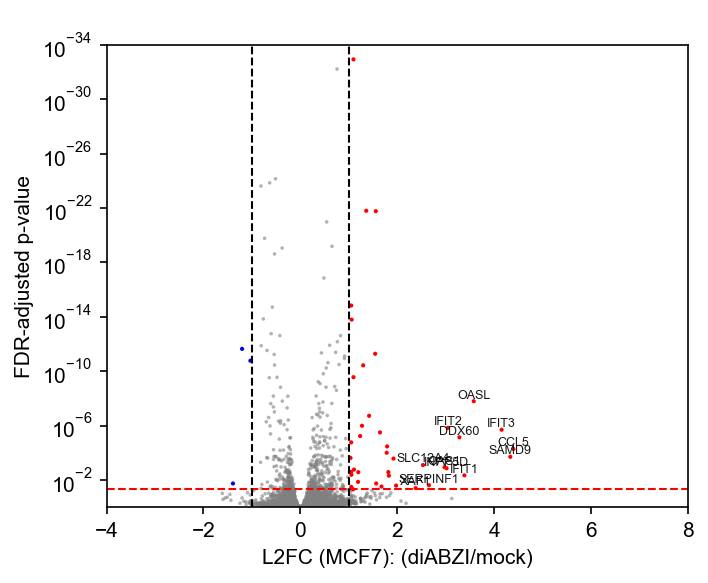

In [14]:
l2fc_cutoff=1
print("L2FC cutoff: "+str(l2fc_cutoff))
genenames_data = genenames_MCF7

diABZI_up_MCF7 = (diABZI_vs_mock_MCF7[2][:,1] > l2fc_cutoff) & (diABZI_vs_mock_MCF7[2][:,5] < 0.05) & (~low_expr_mask_MCF7)
diABZI_down_MCF7 = (diABZI_vs_mock_MCF7[2][:,1] < -l2fc_cutoff) & (diABZI_vs_mock_MCF7[2][:,5] < 0.05) & (~low_expr_mask_MCF7)
print("Num sig upregulated genes: "+str(np.sum(diABZI_up_MCF7))+".  Num sig downregulated genes: "+str(np.sum(diABZI_down_MCF7)))

#make font editable
mpl.rcParams['svg.fonttype']='none' #This is the key line for making SVG text editable
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots(figsize=(5,4),dpi=150)

subplots_titles = [' ']
datasets_names = ['(diABZI/mock)']
l2fc_datasets = [diABZI_vs_mock_MCF7[2][:,1]]
padj_datasets = [diABZI_vs_mock_MCF7[2][:,5]]

axs=[ax]

for i in range(len(axs)):
    fc_datasetlabel = datasets_names[i]
    l2fc_dataset = l2fc_datasets[i]
    padjs = padj_datasets[i]
    print(l2fc_dataset.shape)
    
    axs[i].scatter(l2fc_dataset[(~(diABZI_up_MCF7|diABZI_down_MCF7))&(~low_expr_mask_MCF7)], 
                   padjs[(~(diABZI_up_MCF7|diABZI_down_MCF7))&(~low_expr_mask_MCF7)], s=3, alpha=0.6, color='grey', 
                   edgecolor='none') #rasterized=True allows it to be flattened during SVG
    axs[i].scatter(l2fc_dataset[diABZI_up_MCF7], padjs[diABZI_up_MCF7], s=4, alpha=1, color='red', edgecolor='none')
    axs[i].scatter(l2fc_dataset[diABZI_down_MCF7], padjs[diABZI_down_MCF7], s=4, alpha=1, color='blue', edgecolor='none')

    for gene in np.where(diABZI_up_MCF7)[0]:
        txt_color = 'black'
        alphaval = 0.9
        if l2fc_dataset[gene]>2 and padjs[gene]<0.05:
            if padjs[gene] < 1e-34:
                print(genenames_data[:,1][gene], padjs[gene], np.log10(padjs[gene]))
                axs[i].text(l2fc_dataset[gene], 5e-35, genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)
            else:
                axs[i].text(l2fc_dataset[gene], padjs[gene], genenames_data[:,1][gene],
                    fontsize=6, ha='center', va='bottom', color=txt_color, alpha=alphaval)
     
    axs[i].set_xlim(-4, 8)
    axs[i].set_ylim(1, 1e-34)
    axs[i].axhline(0.05, color='red', linestyle='--', linewidth=1)
    #axs[i].text(2.9, 0.048, 'p=0.05', color='red', horizontalalignment='right')
    axs[i].axvline(l2fc_cutoff, color='black', linestyle='--', linewidth=1)
    axs[i].axvline(-l2fc_cutoff, color='black', linestyle='--', linewidth=1)
    axs[i].semilogy()
    axs[i].set_title(subplots_titles[i])
    axs[i].set_xlabel('L2FC (MCF7): '+datasets_names[i])
    #axs[i].legend(loc='upper right', fancybox=False)

axs[0].set_ylabel('FDR-adjusted p-value')

#Now save as svg
plt.savefig("output_figures/Fig_FBS10-MCF7-diABZIup-RNAseq-Volcano_LabelCutoffL2fc2-pval0p5.svg")


In [15]:
diABZIup_file = open("output_files/diABZIup_MCF7_FBS10.txt","w")
diABZIup_file.write("Names of all genes whose L2FC>"+str(l2fc_cutoff)+", padj<0.05\n")
for gene in np.where(diABZI_up_MCF7)[0]:
    diABZIup_file.write(genenames_data[:,1][gene]+'\n')
diABZIup_file.close()

diABZIdown_file = open("output_files/diABZIdown_MCF7_FBS10.txt","w")
diABZIdown_file.write("Names of all genes whose L2FC<"+str(-l2fc_cutoff)+", padj<0.05\n")
for gene in np.where(diABZI_down_MCF7)[0]:
    diABZIdown_file.write(genenames_data[:,1][gene]+'\n')
diABZIdown_file.close()

### 3. Plot expression heatmaps

In [16]:
#Color scale=Normalized against mock average: for each sample, divide by mock avg. Finally, take the log2 of all conditions

mock_avg_MCF7 = np.mean(MCF7_matrx_reordered[:, :2],axis=1, keepdims=True)
#Divide each element by mock avg
l2fc_mockavg_norm_MCF7 = np.log2((MCF7_matrx_reordered+0.1) / (mock_avg_MCF7+0.1))

mock_avg_HCC2429 = np.mean(HCC2429_matrx_reordered[:, :2],axis=1, keepdims=True)
#Divide each element by mock avg
l2fc_mockavg_norm_HCC2429 = np.log2((HCC2429_matrx_reordered+0.1) / (mock_avg_HCC2429+0.1))

50
3


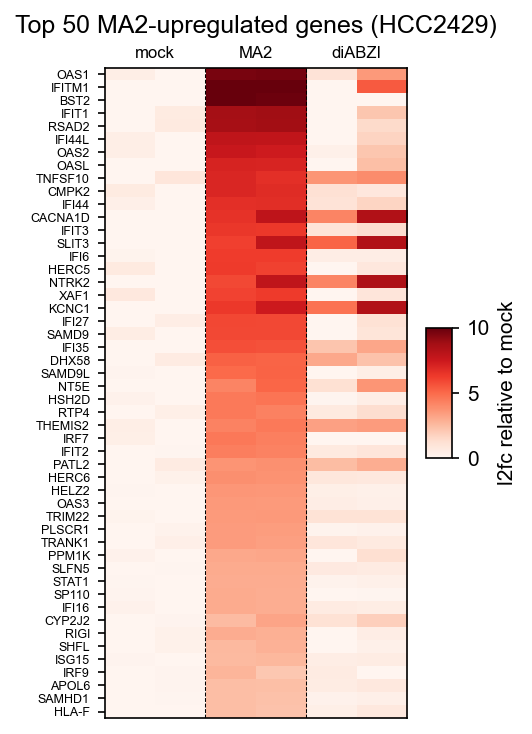

In [17]:
#Plot the top 50, HCC2429
top_n = 50 #set number of top genes to keep

mpl.rcParams['svg.fonttype']='none' #This is the key line for making SVG text editable
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots(figsize=(3.5,5),dpi=150)

#First, filter for only those that passed a p-value threshold
filter_sig = (MA2_vs_mock_HCC2429[2][:,5] < 0.05)
#Second, sort matrix by l2fc computed by DESeq2
sort_l2fc = np.argsort(-MA2_vs_mock_HCC2429[2][:,1][filter_sig]) #Note by default np.argsort provides indices in ascending order; minus sign gives descending
matrix = l2fc_mockavg_norm_HCC2429[:,:]

plt.axvline(2-0.5, color='black', linestyle='--', linewidth=0.5) 
plt.axvline(4-0.5, color='black', linestyle='--', linewidth=0.5) 
plt.axvline(6-0.5, color='black', linestyle='--', linewidth=0.5) 

#sort by treatment average expression
im=ax.imshow(matrix[filter_sig][sort_l2fc][:top_n,:], aspect="auto", cmap='Reds', vmin=0, vmax=10,
             interpolation="none")
ax.set_title('Top 50 MA2-upregulated genes (HCC2429)')

# Set row labels
row_labels = genenames_HCC2429[:,1][filter_sig][sort_l2fc][:top_n]
#for ele in row_labels:
    #print(ele)
print(len(row_labels))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=6)

col_labels = ['mock','MA2','diABZI']
print(len(col_labels))
ax.set_xticks(2*np.arange(len(col_labels))+0.5)
ax.set_xticklabels(col_labels, fontsize=8)

# Move col labels to the top
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.tick_params(axis='x', which='both', length=0)

cbar = plt.colorbar(im, ax=ax, shrink=0.2, aspect=5, label='l2fc relative to mock')
fig.tight_layout()

plt.savefig("output_figures/Fig_HCC2429-MA2up-RNAseq-Heatmap_top50.svg")


50
3


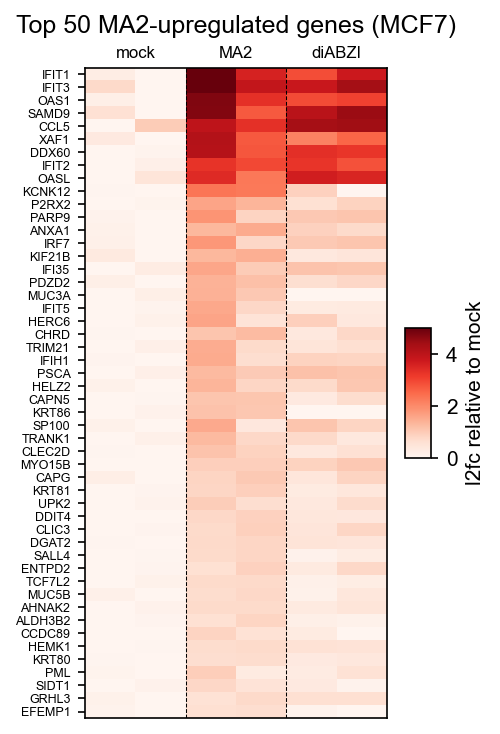

In [18]:
#Plot the top 50, MCF7

top_n = 50 #set number of top genes to keep

mpl.rcParams['svg.fonttype']='none' #This is the key line for making SVG text editable
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots(figsize=(3.5,5),dpi=150)
#First, filter for only those that passed a p-value threshold
filter_sig = (MA2_vs_mock_MCF7[2][:,5] < 0.05)
#Second, sort matrix by l2fc computed by DESeq2
sort_l2fc = np.argsort(-MA2_vs_mock_MCF7[2][:,1][filter_sig]) #Note by default np.argsort provides indices in ascending order; minus sign gives descending

matrix = l2fc_mockavg_norm_MCF7[:,:]

plt.axvline(2-0.5, color='black', linestyle='--', linewidth=0.5) 
plt.axvline(4-0.5, color='black', linestyle='--', linewidth=0.5) 
plt.axvline(6-0.5, color='black', linestyle='--', linewidth=0.5) 

#sort by treatment average expression
im=ax.imshow(matrix[filter_sig][sort_l2fc][:top_n,:], aspect="auto", cmap='Reds', vmin=0, vmax=5,
             interpolation="none")
ax.set_title('Top 50 MA2-upregulated genes (MCF7)')

# Set row labels
row_labels = genenames_MCF7[:,1][filter_sig][sort_l2fc][:top_n]
#for ele in row_labels:
    #print(ele)
print(len(row_labels))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=6)

col_labels = ['mock','MA2','diABZI']
print(len(col_labels))
ax.set_xticks(2*np.arange(len(col_labels))+0.5)
ax.set_xticklabels(col_labels, fontsize=8)

# Move col labels to the top
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.tick_params(axis='x', which='both', length=0)

cbar = plt.colorbar(im, ax=ax, shrink=0.2, aspect=5, label='l2fc relative to mock')
fig.tight_layout()

plt.savefig("output_figures/Fig_FBS10-MCF7-MA2up-RNAseq-Heatmap_top50.svg")


In [19]:
print("Finished running successfully.")

Finished running successfully.
